<p><font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>

<p><font size="5" color='grey'> <b>
Supervisor Pattern – Deep Dive
</b></font> </br></p>

---

In [ ]:
#@title 🔧 Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul

import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]    = "M20-Supervisor-Pattern"
os.environ["LANGSMITH_ENDPOINT"]   = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    get_model_profile,
    extract_thinking,
    load_prompt,
    show_trace
)

setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.12
langchain-chroma                         1.1.0
langchain-classic                        1.0.3
langchain-community                      0.4.1
langchain-core                           1.2.19
langchain-ollama                         1.0.1
langchain-openai                         1.1.11
langchain-text-splitters                 1.1.1
langgraph                                1.1.2
langgraph-checkpoint                     4.0.1
langgraph-prebuilt                       1.0.8
langgraph-sdk                            0.3.11

IP-Adresse: 35.231.165.77
Hostname: 77.165.231.35.bc.googleusercontent.com
Stadt: North Charleston
Region: South Carolina
Land: US
Koordinaten: 32.8546,-79.9748
Provider: AS396982 Google LLC
Postleitzahl: 29415
Zeitzone: America/New_

In [ ]:
#@title 📦 Pakete installieren{ display-mode: "form" }
install_packages([
    'wikipedia',
])

🔄 Installiere wikipedia...
✅ wikipedia erfolgreich installiert und importiert


# 1 | Übersicht
---

***Multi-Agent Patterns*** zeigte drei Multi-Agent-Patterns auf hohem Niveau: Supervisor, Hierarchisch, Pipeline.  
**Dieses Modul** vertieft das **Supervisor Pattern** mit realen Tools, Iterations-Schutz und Fehlerbehandlung.

| Thema | Multi-Agent | Supervisor |
|-------|-----|-----|
| Supervisor-Grundkonzept | ✅ Überblick | ✅ Deep Dive |
| Worker Agents | Einfache LLM-Calls | **Mit echten Tools** |
| Iterations-Schutz | ❌ | ✅ **Counter + recursion_limit** |
| Fehlerbehandlung | ❌ | ✅ **Try/Except + Retry-Logik** |
| Supervisor-Begründung | ❌ | ✅ **reasoning-Feld** |
| LangSmith-Debugging | Basis | **Message-Analyse + Tracing** |


In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Supervisor-Architektur mit Tool-Agents</font> </br></p>

diagram = '''
flowchart TD
    START([START]) --> SUP["🎯 Supervisor\nwith_structured_output()"]

    SUP -->|"recherche"| R["🔍 Recherche-Agent\nWikipedia-Tool"]
    SUP -->|"schreiben"| W["✍️ Schreib-Agent\nText-Tools"]
    SUP -->|"code"| C["💻 Code-Agent\nPython-REPL"]
    SUP -->|"FINISH"| END([END])

    R -->|"AIMessage\n(name=Recherche)"| SUP
    W -->|"AIMessage\n(name=Schreiben)"| SUP
    C -->|"AIMessage\n(name=Code)"| SUP

    R --- RT["📚 wikipedia\n@tool"]
    W --- WT["🔢 count_words\n@tool"]
    C --- CT["▶️ python_repl\n@tool"]

    style SUP fill:#FF9800,color:#fff
    style R   fill:#2196F3,color:#fff
    style W   fill:#4CAF50,color:#fff
    style C   fill:#9C27B0,color:#fff
    style RT  fill:#E3F2FD
    style WT  fill:#E8F5E9
    style CT  fill:#F3E5F5
'''
mermaid(diagram, width=820)

# 2 | Worker Agents mit Tools
---

In *Multi-Agent Patterns* waren die Worker Agents einfache LLM-Aufrufe ohne Tool-Nutzung.  
In diesem Modul erhält **jeder Worker Agent eigene Tools** – das ist die reale Praxis.

**Tool-Integration in Worker Agents:**

```python
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def wikipedia(query: str) -> str:
    """Sucht Informationen in Wikipedia."""
    ...

# Worker Agent = ReAct-Agent mit Tools
research_agent = create_react_agent(
    llm,
    tools=[wikipedia],
    prompt=SystemMessage("Du bist Recherche-Spezialist...")
)
```

**Warum `create_react_agent`?**

| Eigenschaft | Einfacher LLM-Call | ReAct-Agent mit Tools |
|-------------|-------------------|----------------------|
| Tool-Nutzung | ❌ | ✅ Automatisch |
| Multi-Step | ❌ (ein Schritt) | ✅ (Think → Act → Observe) |
| Fehler-Recovery | ❌ | ✅ Retry möglich |
| Aufwand | Gering | Mittel |

In [31]:
#@title
#@markdown   <p><font size="4" color='green'>  ReAct-Agent als Worker</font> </br></p>

diagram = '''
flowchart LR
    IN[/"Aufgabe vom\nSupervisor"/] --> THINK["🤔 Think\nWas brauche\nich?"]
    THINK --> ACT["⚡ Act\nTool aufrufen"]
    ACT --> OBS["👁️ Observe\nErgebnis lesen"]
    OBS -->|"Noch nicht fertig"| THINK
    OBS -->|"Fertig"| OUT[/"AIMessage\n(name=Agent)"/]

    ACT --- T1["📚 wikipedia"]
    ACT --- T2["🌐 web_search"]
    ACT --- T3["▶️ python_repl"]

    style THINK fill:#FF9800,color:#fff
    style ACT   fill:#2196F3,color:#fff
    style OBS   fill:#4CAF50,color:#fff
'''
mermaid(diagram, width=850)

In [32]:
# ── Imports ───────────────────────────────────────────────────────────────
from typing import Annotated, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent
from IPython.display import Image as IPImage
import uuid

# ── Konfigurationskonstanten ───────────────────────────────────────────────
MAX_RETRIES = 3   # API-Retry-Versuche bei transienten Fehlern (with_retry)

# ── LLM ───────────────────────────────────────────────────────────────────
llm = init_chat_model("openai:gpt-4o-mini", temperature=0.0)

In [33]:
# ── Research Tools ────────────────────────────────────────────────────────
import wikipedia as wiki_lib

@tool
def wikipedia_suche(suchbegriff: str) -> str:
    """Sucht Informationen in Wikipedia. Fuer Fakten, Definitionen, Geschichte.
    Gibt eine kurze Zusammenfassung zurueck.
    TIPP: Englische Begriffe liefern fuer Programmier-Themen bessere Ergebnisse.
    """
    # Englische Wikipedia nutzen: fuer Programmier-Themen vollstaendiger.
    # Deutsche Wikipedia hat viele Fachbegriffe als Redirect oder gar nicht.
    wiki_lib.set_lang("en")
    try:
        return wiki_lib.summary(suchbegriff, sentences=5)
    except wiki_lib.exceptions.DisambiguationError as e:
        # Mehrdeutiger Begriff: erstes konkretes Ergebnis versuchen
        try:
            return wiki_lib.summary(e.options[0], sentences=5)
        except Exception:
            return f"Mehrdeutig. Alternativen: {e.options[:3]}"
    except wiki_lib.exceptions.PageError:
        # Seite nicht gefunden: mit "programming" oder "Python" ergaenzen
        try:
            return wiki_lib.summary(f"{suchbegriff} programming", sentences=5)
        except Exception as e2:
            return f"Artikel nicht gefunden: {suchbegriff}. Fehler: {e2}"
    except Exception as e:
        return f"Wikipedia-Suche fehlgeschlagen: {str(e)}"

@tool
def wichtige_fakten(thema: str) -> str:
    """Extrahiert die wichtigsten Fakten zu einem Thema als Stichpunkte.
    Nutze dies nach wikipedia_suche um die Kernpunkte herauszuarbeiten."""
    return (f"Bitte extrahiere 3-5 Kernfakten zu '{thema}' "
            "aus den bereits gefundenen Informationen.")

# ── Think Tool (Strategische Reflexion) ───────────────────────────────────
@tool
def think(reflection: str) -> str:
    """Strategisches Nachdenken nach einem Tool-Ergebnis.

    Nutze dieses Tool nach jeder wikipedia_suche:
    - Habe ich genug Informationen fuer meine Aufgabe?
    - Welche Aspekte fehlen noch?
    - Welcher naechste Schritt bringt den groessten Mehrwert?

    Args:
        reflection: Deine Analyse des Fortschritts und geplante naechste Schritte
    """
    return f"Reflexion notiert: {reflection}"

# ── Writing Tools ─────────────────────────────────────────────────────────
@tool
def wort_zaehlen(text: str) -> str:
    """Zaehlt Woerter in einem Text. Nuetzlich um Wortlimits einzuhalten."""
    anzahl = len(text.split())
    return f"Der Text hat {anzahl} Woerter."

@tool
def gliederung_erstellen(thema: str) -> str:
    """Erstellt eine strukturierte Gliederung fuer ein Thema."""
    return (
        f"Gliederung fuer '{thema}':\n"
        "1. Einleitung & Definition\n"
        "2. Historische Entwicklung\n"
        "3. Aktuelle Anwendungen\n"
        "4. Vor- und Nachteile\n"
        "5. Fazit & Ausblick"
    )

# ── Code Tools ────────────────────────────────────────────────────────────
@tool
def python_ausfuehren(code: str) -> str:
    """Fuehrt einfachen Python-Code aus und gibt das Ergebnis zurueck.
    Fuer Berechnungen, Demonstrationen und kurze Algorithmen."""
    verboten = ["import os", "import sys", "exec(", "__import__", "open("]
    if any(v in code for v in verboten):
        return "Nicht erlaubt: System-Importe und exec() sind gesperrt."
    try:
        ergebnis = eval(code)
        return f"Ergebnis: {ergebnis}"
    except SyntaxError:
        ns: dict = {}
        exec(compile(code, "<string>", "exec"), ns)
        return f"Ausgefuehrt. Lokale Variablen: {list(ns.keys())}"
    except Exception as e:
        return f"Fehler: {type(e).__name__}: {e}"

@tool
def code_pruefen(code: str) -> str:
    """Prueft Python-Code auf haeufige Probleme und Best-Practice-Verletzungen.
    Gibt Hinweise zur Codequalitaet zurueck."""
    hinweise = []
    if "print(" in code:
        hinweise.append("Tipp: In Produktion logging statt print() verwenden.")
    if len(code.split("\n")) > 30:
        hinweise.append("Tipp: Funktion sehr lang (>30 Zeilen) - Refactoring erwaegen.")
    if "try" not in code and "def " in code:
        hinweise.append("Tipp: Funktionen ohne Fehlerbehandlung koennen abstürzen.")
    return "\n".join(hinweise) if hinweise else "Code sieht solide aus!"

print("✅ Tools definiert:")
print("   wikipedia_suche  (en-Wikipedia + PageError-Handling)")
print("   think            (strategische Reflexion nach Tool-Calls)")
print("   wichtige_fakten  (fuer Aufgabe 1 - Anti-Pattern-Demo)")
print("   wort_zaehlen, gliederung_erstellen")
print("   python_ausfuehren, code_pruefen")

✅ Tools definiert:
   wikipedia_suche  (en-Wikipedia + PageError-Handling)
   think            (strategische Reflexion nach Tool-Calls)
   wichtige_fakten  (fuer Aufgabe 1 - Anti-Pattern-Demo)
   wort_zaehlen, gliederung_erstellen
   python_ausfuehren, code_pruefen


In [34]:
# ── Spezialisierte Worker Agents ─────────────────────────────────────────
# Jeder Agent hat einen klaren Fokus und nur die Tools, die er braucht.
# ACHTUNG: wichtige_fakten ist NICHT im recherche_agent!
#   Das Tool gibt eine Aufgaben-Beschreibung zurück, kein Ergebnis.
#   Der Agent würde es als neue Aufgabe interpretieren → extra Schritte
#   → recursion_limit überschritten. (Lernhinweis für Aufgabe 1)

# 1. Recherche-Agent – wikipedia_suche + think (strategische Reflexion)
#    think: Nach jeder Suche reflektiert der Agent ob er genug Infos hat.
#    Verhindert unnötige Folgesuchen und verbessert die Fokussierung.
recherche_agent = create_react_agent(
    llm,
    tools=[wikipedia_suche, think],
    prompt=SystemMessage(
        "Du bist Recherche-Spezialist. "
        "Nutze wikipedia_suche um Fakten zu recherchieren. "
        "Nutze think nach jeder Suche: Hast du genug? Was fehlt noch? "
        "Fasse die wichtigsten Informationen prägnant zusammen. "
        "Antworte auf Deutsch."
    )
)

# 2. Schreib-Agent – Gliederung und Wort-Zählung
schreib_agent = create_react_agent(
    llm,
    tools=[wort_zaehlen, gliederung_erstellen],
    prompt=SystemMessage(
        "Du bist Schreib-Spezialist. Erstelle gut strukturierte Texte. "
        "Nutze gliederung_erstellen für Struktur und wort_zaehlen "
        "zum Einhalten von Wortlimits. Klare Sprache. Deutsch."
    )
)

# 3. Code-Agent – Python ausführen und prüfen
code_agent = create_react_agent(
    llm,
    tools=[python_ausfuehren, code_pruefen],
    prompt=SystemMessage(
        "Du bist Code-Spezialist. Schreibe sauberen, kommentierten Python-Code. "
        "Teste ihn mit python_ausfuehren und prüfe ihn mit code_pruefen. "
        "Erkläre deinen Code auf Deutsch."
    )
)

print("✅ Worker Agents erstellt:")
print("   recherche_agent → [wikipedia_suche, think]")
print("   schreib_agent   → [wort_zaehlen, gliederung_erstellen]")
print("   code_agent      → [python_ausfuehren, code_pruefen]")

✅ Worker Agents erstellt:
   recherche_agent → [wikipedia_suche, think]
   schreib_agent   → [wort_zaehlen, gliederung_erstellen]
   code_agent      → [python_ausfuehren, code_pruefen]


# 3 | Supervisor mit Begründung & Iterations-Schutz
---

> **📚 Modell-Auswahl: Supervisor vs. Worker**
>
> In diesem Modul wird die Modell-Rollentrennung erstmals in der Praxis eingesetzt:
> - **Supervisor** (`o3`): trifft Routing-Entscheidungen — starkes Reasoning erforderlich
> - **Worker** (`gpt-4o-mini`): erzeugt Inhalte — Geschwindigkeit und Kosten im Vordergrund
>
> ⚠️ `o3` akzeptiert **keinen** `temperature`-Parameter.
>
> → [Modell-Auswahl Guide](https://ralf-42.github.io/Agenten/frameworks/Modell_Auswahl_Guide.html)


<p><font color='black' size="5">
Erweiterungen gegenüber *Multi-Agent Patterns*
</font></p>

**1. Begründungs-Feld im Supervisor:**
Der Supervisor erklärt jede Entscheidung – unverzichtbar für Debugging.

```python
class SupervisorEntscheidung(BaseModel):
    naechster: Literal["recherche", "schreiben", "code", "FINISH"]
    begruendung: str  # ← NEU: Warum dieser Agent?
```

**2. Iterations-Schutz im State:**
Ein Zähler verhindert endlose Schleifen – unabhängig vom `recursion_limit`.

```python
class SupervisorState(TypedDict):
    messages:    Annotated[list, add_messages]
    aufgabe:     str
    naechster:   str
    iterationen: int  # ← NEU: Schutz vor Endlosschleifen
    max_iter:    int  # ← NEU: Konfigurierbare Grenze
```

**3. Sicherheitsnetz im Supervisor-Node:**
```python
def supervisor_node(state):
    if state["iterationen"] >= state["max_iter"]:
        return {"naechster": "FINISH"}  # Zwangsbeendigung
    ...
```

In [35]:
#@markdown   <p><font size="4" color='green'>  Supervisor mit Iterations-Schutz</font> </br></p>

diagram = '''
flowchart TD
    START([START]) --> SUP

    subgraph Guardrails [🛡️ Sicherheits-Layer]
        SUP{"🎯 Supervisor\nIterationen < max_iter?"}
        note1["Counter-Check"]
        note2["recursion_limit (System)"]
    end

    SUP -->|"JA"| ROUTE["🔀 Router\nsupervisor_router()"]
    SUP -->|"NEIN: Zwang-Abbruch"| END([END])

    ROUTE -->|"recherche"| R["🔍 Recherche"]
    ROUTE -->|"schreiben"| W["✍️ Schreiben"]
    ROUTE -->|"code"| C["💻 Code"]
    ROUTE -->|"FINISH"| END

    R & W & C -->|"iterationen++"| SUP

    %% Styling
    style SUP     fill:#FF9800,color:#fff,stroke:#e68a00,stroke-width:2px
    style ROUTE   fill:#607D8B,color:#fff
    style R       fill:#2196F3,color:#fff
    style W       fill:#4CAF50,color:#fff
    style C       fill:#9C27B0,color:#fff
    style END     fill:#f44336,color:#fff
    style Guardrails fill:#fffde7,stroke:#fbc02d,stroke-dasharray: 5 5
'''
mermaid(diagram, width=820)

In [36]:
# ── State mit Iterations-Schutz ───────────────────────────────────────────
class SupervisorState(TypedDict):
    messages:    Annotated[list, add_messages]  # Gesamte Nachrichten-Historie
    aufgabe:     str    # Original-Aufgabe (unveraenderlich)
    naechster:   str    # Routing-Entscheidung des Supervisors
    iterationen: int    # Wie oft haben Worker Agents gearbeitet?
    max_iter:    int    # Maximale Anzahl Worker-Runs

# ── Pydantic-Modell mit Begruendungs-Feld ─────────────────────────────────
class SupervisorEntscheidung(BaseModel):
    """Strukturierte Routing-Entscheidung des Supervisors."""
    naechster: Literal["recherche", "schreiben", "code", "FINISH"] = Field(
        description="Naechster Agent oder FINISH wenn die Aufgabe vollstaendig ist."
    )
    begruendung: str = Field(
        description="Kurze Begruendung fuer diese Entscheidung (1-2 Saetze)."
    )

# o3 akzeptiert keinen temperature-Parameter (API-Fehler bei temperature=0.0)
# .with_retry(): schützt vor transienten API-Fehlern (Netzwerk, Rate-Limits)
supervisor_llm = (
    init_chat_model("openai:o3")
    .with_structured_output(SupervisorEntscheidung)
    .with_retry(stop_after_attempt=MAX_RETRIES)
)

# Supervisor-Prompt: XML-Sektionen + History-Lese-Anleitung + Hard Limits
SUPERVISOR_SYSTEM = (
    "Du koordinierst ein Experten-Team.\n\n"
    "<Team>\n"
    "- recherche: Recherchiert Fakten (Wikipedia). Zuerst aufrufen.\n"
    "- schreiben: Erstellt strukturierte Texte. Nach der Recherche.\n"
    "- code:      Schreibt Python-Code. Bei Code-Aufgaben.\n"
    "</Team>\n\n"
    "<Workflow>\n"
    "Typische Reihenfolgen:\n"
    "  Frage/Report:  recherche -> schreiben -> FINISH\n"
    "  Code-Aufgabe:  recherche -> code -> FINISH\n"
    "  Nur Code:      code -> FINISH\n\n"
    "Wie du die Nachrichtenhistorie liest:\n"
    "  name=Recherche -> recherche war bereits aktiv\n"
    "  name=Schreiben -> schreiben war bereits aktiv\n"
    "  name=Code      -> code war bereits aktiv\n"
    "  name=System + Fehler -> Agent fehlgeschlagen (NICHT nochmal schicken!)\n"
    "</Workflow>\n\n"
    "<Hard Limits>\n"
    "Agent-Budget: maximal 2 Agenten-Aufrufe pro Aufgabe.\n"
    "Sofort FINISH wenn:\n"
    "- Alle benoetigen Agenten waren aktiv (Erfolg oder Fehler)\n"
    "- Die Aufgabe vollstaendig beantwortet ist\n"
    "</Hard Limits>\n\n"
    "<Rules>\n"
    "1. Pruefe die Message-Namen VOR jeder Entscheidung.\n"
    "2. Jeden Agenten maximal EINMAL schicken (Erfolg ODER Fehler).\n"
    "3. Wenn alle benoetigen Agenten dran waren: FINISH.\n"
    "4. Bei Fehlern: Naechsten Agenten nehmen, nicht wiederholen.\n"
    "</Rules>"
)

print("✅ State und Supervisor-LLM konfiguriert")
print(f"   supervisor_llm: o3 + with_structured_output + with_retry(stop_after_attempt={MAX_RETRIES})")

✅ State und Supervisor-LLM konfiguriert
   supervisor_llm: o3 + with_structured_output + with_retry(stop_after_attempt=3)


In [37]:
# ── Supervisor Node ───────────────────────────────────────────────────────
def supervisor_node(state: SupervisorState) -> dict:
    """Liest die Situation, entscheidet wer als nächstes arbeitet."""
    if state["iterationen"] >= state["max_iter"]:
        mprint(f"⚠️ **Iterations-Limit ({state['max_iter']}). Erzwinge FINISH.**")
        return {"naechster": "FINISH"}

    entscheidung = supervisor_llm.invoke([
        SystemMessage(SUPERVISOR_SYSTEM),
        HumanMessage(f"Aufgabe: {state['aufgabe']}"),
        *state["messages"],
    ])
    mprint(f"**👔 Supervisor →** `{entscheidung.naechster}`  _{entscheidung.begruendung}_")
    return {"naechster": entscheidung.naechster}


# ── Worker Node Factory ────────────────────────────────────────────────────
# create_react_agent nutzt intern einen eigenen LangGraph-Graphen.
# Jeder ReAct-Schritt zählt als Graph-Step:
#   1 Tool-Aufruf = 2 Steps (agent-node + tools-node)
#   3 Tool-Aufrufe = 6 Steps + 1 abschließender LLM-Call = 7 Steps
# Mit max. 5-6 Tool-Calls pro Agent reicht limit=35 sicher aus.
INNER_AGENT_CFG = {"recursion_limit": 35}

def make_worker_node(agent, name: str):
    """Worker-Node für LangGraph.

    Übergibt dem inneren ReAct-Agenten ein eigenes recursion_limit,
    damit er genug Schritte für Tool-Calls hat.
    Fängt GraphRecursionError und andere Exceptions ab, damit der
    äußere Supervisor-Graph nicht abstürzt.
    """
    def worker_node(state: SupervisorState) -> dict:
        mprint(f"\n**🤖 {name}** arbeitet...")
        kontext = f"Aufgabe: {state['aufgabe']}"
        if state["messages"]:
            bisherige = "\n".join(
                f"{getattr(m, 'name', 'User')}: {m.content[:300]}"
                for m in state["messages"]
            )
            kontext += f"\n\nBisherige Arbeit des Teams:\n{bisherige}"

        try:
            result = agent.invoke(
                {"messages": [HumanMessage(kontext)]},
                config=INNER_AGENT_CFG,
            )
            letzte_msg = result["messages"][-1]
            # Weiches Versagen: "Sorry, need more steps"
            if ("sorry" in letzte_msg.content.lower()
                    and "more steps" in letzte_msg.content.lower()):
                raise RuntimeError(
                    f"Inneres recursion_limit erreicht "
                    f"(aktuell: {INNER_AGENT_CFG['recursion_limit']})."
                )
            return {
                "messages":    [AIMessage(content=letzte_msg.content, name=name)],
                "iterationen": state["iterationen"] + 1,
            }
        except Exception as e:
            fehler_msg = (
                f"❌ {name} fehlgeschlagen: {type(e).__name__}: {e}"
            )
            mprint(f"  ⚠️ {fehler_msg}")
            return {
                "messages":    [AIMessage(content=fehler_msg, name="System")],
                "iterationen": state["iterationen"] + 1,
            }

    worker_node.__name__ = f"{name}_node"
    return worker_node


# ── Router ─────────────────────────────────────────────────────────────────
def supervisor_router(state: SupervisorState) -> str:
    naechster = state.get("naechster", "FINISH")
    return "__end__" if naechster == "FINISH" else naechster


recherche_node = make_worker_node(recherche_agent, "Recherche")
schreiben_node = make_worker_node(schreib_agent,   "Schreiben")
code_node      = make_worker_node(code_agent,      "Code")

print("✅ Supervisor-Node, Worker-Nodes und Router bereit")
print(f"   INNER_AGENT_CFG: recursion_limit={INNER_AGENT_CFG['recursion_limit']}")

✅ Supervisor-Node, Worker-Nodes und Router bereit
   INNER_AGENT_CFG: recursion_limit=35


# 4 | Graph aufbauen
---


<p><font color='black' size="5">
COMPILE – Supervisor-Graph assemblieren
</font></p>

**Zwei Schutzebenen gegen Endlosschleifen:**

| Schutz | Mechanismus | Wann greift er? |
|--------|------------|----------------|
| `iterationen >= max_iter` | Feld im State | Supervisor prüft vor jeder Entscheidung |
| `recursion_limit` | LangGraph intern | Maximale Graph-Schritt-Anzahl |

```python
# Beide Grenzen konfigurieren:
graph.invoke(input, config={"recursion_limit": 30})
#                             ↑ je 2 Schritte pro Agent-Runde
```

In [38]:
# ── COMPILE ───────────────────────────────────────────────────────────────
builder = StateGraph(SupervisorState)

# Nodes hinzufügen
builder.add_node("supervisor", supervisor_node)
builder.add_node("recherche",  recherche_node)
builder.add_node("schreiben",  schreiben_node)
builder.add_node("code",       code_node)

# Einstiegspunkt
builder.add_edge(START, "supervisor")

# Bedingtes Routing vom Supervisor
builder.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "recherche": "recherche",
        "schreiben": "schreiben",
        "code":      "code",
        "__end__":   END,           # Explizite path_map – korrekte Visualisierung
    }
)

# Nach jedem Worker zurück zum Supervisor (Sternförmige Topologie)
builder.add_edge("recherche", "supervisor")
builder.add_edge("schreiben", "supervisor")
builder.add_edge("code",      "supervisor")

# Kompilieren
supervisor_graph = builder.compile()
print("✅ Supervisor-Graph kompiliert")

✅ Supervisor-Graph kompiliert


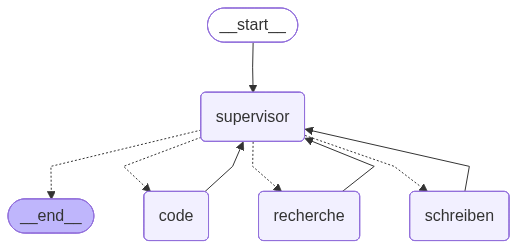

In [39]:
# ── VIZ ───────────────────────────────────────────────────────────────────
display(IPImage(supervisor_graph.get_graph().draw_mermaid_png()))

In [ ]:
# ── TESTS: Task 1 – Recherche + Schreiben ─────────────────────────────────
run_cfg = {"run_name": "M20-Kap4.1-Supervisor", "tags": ["m20", "supervisor"],
           "recursion_limit": 30}

aufgabe1 = "Erkläre die Grundprinzipien von Large Language Models und schreibe einen strukturierten Überblick."

result1 = supervisor_graph.invoke(
    {
        "messages":    [],
        "aufgabe":     aufgabe1,
        "naechster":   "",
        "iterationen": 0,
        "max_iter":    5,
    },
    config=run_cfg
)

mprint("## 🎯 Ergebnis: Recherche + Schreiben")
mprint(f"**Aufgabe:** {aufgabe1}\n")
mprint(f"**Iterationen:** {result1['iterationen']} von max. 5\n")
mprint("---")
for msg in result1["messages"]:
    agent = getattr(msg, "name", None) or "System"
    mprint(f"**[{agent}]**\n{msg.content}\n---")

**👔 Supervisor →** `recherche`  _Zunächst Fakten und Informationen zu LLMs recherchieren, dann strukturiert ausformulieren lassen._


**🤖 Recherche** arbeitet...

**👔 Supervisor →** `schreiben`  _Recherche‐Agent hat bereits Basisinformationen geliefert; jetzt soll der Schreiben-Agent daraus einen strukturierten, ausgearbeiteten Überblick erstellen._


**🤖 Schreiben** arbeitet...

**👔 Supervisor →** `FINISH`  _Recherche- und Schreiben-Agenten waren aktiv, und die Aufgabe ist vollständig beantwortet; daher abschließen._

...

**Aufgabe:** Erkläre die Grundprinzipien von Large Language Models und schreibe einen strukturierten Überblick.


**Iterationen:** 2 von max. 5


---

**[Recherche]**
Hier ist ein strukturierter Überblick über die Grundprinzipien von Large Language Models (LLMs):

### 1. Definition
- **Large Language Models (LLMs)** sind rechnergestützte Modelle, die auf einer großen Menge an Daten trainiert werden und für Aufgaben der natürlichen Sprachverarbeitung, insbesondere der Sprachgenerierung, konzipiert sind.

### 2. Architektur
- Die größten und leistungsfähigsten LLMs sind **Generative Pre-trained Transformers (GPTs)**.
- LLMs bestehen aus **Milliarden bis Billionen von Parametern** und funktionieren als allgemeine Sequenzmodelle, die Text generieren, zusammenfassen, übersetzen und über ihn nachdenken können.

### 3. Training
- LLMs werden auf umfangreichen Textkorpora trainiert, um Vorhersagefähigkeiten in Bezug auf Syntax, Semantik und Ontologien zu erlangen.
- Sie können für spezifische Aufgaben **feinjustiert** oder durch **Prompt Engineering** geleitet werden.

### 4. Herausforderungen und Limitationen
- **Algorithmische Verzerrungen**: LLMs können Verzerrungen und Ungenauigkeiten aus den Trainingsdaten übernehmen, was zu unfairen oder diskriminierenden Ergebnissen führen kann.
- **Ethische Implikationen**: Themen wie Fairness, Verantwortung, Transparenz und Datenschutz sind kritisch, insbesondere wenn LLMs menschliche Entscheidungen beeinflussen oder automatisieren.
- **Gesellschaftliche Auswirkungen**: Die Nutzung von LLMs kann zu Herausforderungen wie technologischer Arbeitslosigkeit und der Verbreitung von Fehlinformationen führen.

### 5. Ethische Überlegungen
- Die Ethik von KI umfasst die Gestaltung von **Artificial Moral Agents (AMAs)**, die moralisch handeln oder so erscheinen sollen.
- Wichtige ethische Fragestellungen betreffen die Verantwortung für Entscheidungen, die von LLMs getroffen werden, sowie die moralische Behandlung von KI-Systemen.

### Fazit
Large Language Models sind komplexe Systeme mit weitreichenden Anwendungen und Herausforderungen. Ihre Entwicklung und Nutzung erfordert sorgfältige Überlegungen zu ethischen und gesellschaftlichen Aspekten, um sicherzustellen, dass sie verantwortungsvoll eingesetzt werden.
---

**[Schreiben]**
Hier ist ein strukturierter Überblick über die Grundprinzipien von Large Language Models (LLMs):

### 1. Einleitung & Definition
- **Large Language Models (LLMs)** sind rechnergestützte Modelle, die auf einer großen Menge an Daten trainiert werden und für Aufgaben der natürlichen Sprachverarbeitung, insbesondere zur Generierung und Analyse von Texten, eingesetzt werden.

### 2. Historische Entwicklung
- Die Entwicklung von LLMs begann mit einfachen statistischen Modellen und hat sich über neuronale Netze zu komplexen Architekturen wie Transformer-Modellen weiterentwickelt.

### 3. Aktuelle Anwendungen
- LLMs finden Anwendung in verschiedenen Bereichen, darunter:
  - Textgenerierung (z.B. Chatbots, kreative Schreibassistenz)
  - Übersetzungen
  - Sentiment-Analyse
  - Automatisierte Kundenbetreuung

### 4. Vor- und Nachteile
- **Vorteile:**
  - Hohe Flexibilität und Anpassungsfähigkeit
  - Fähigkeit, kontextuelle Informationen zu verarbeiten
- **Nachteile:**
  - Hoher Rechenaufwand
  - Potenzielle Verzerrungen in den Trainingsdaten

### 5. Fazit & Ausblick
- LLMs haben das Potenzial, die Art und Weise, wie wir mit Technologie interagieren, grundlegend zu verändern. Zukünftige Entwicklungen könnten die Effizienz und Ethik dieser Modelle weiter verbessern.

Dieser Überblick umfasst die grundlegenden Aspekte von LLMs und bietet eine klare Struktur für ein tiefergehendes Verständnis.
---

In [ ]:
# ── TESTS: Task 2 – Recherche + Code ─────────────────────────────────────
aufgabe2 = (
    "Recherchiere die Fibonacci-Folge und schreibe dann Python-Code "
    "für eine effiziente Implementierung mit Caching."
)

result2 = supervisor_graph.invoke(
    {
        "messages":    [],
        "aufgabe":     aufgabe2,
        "naechster":   "",
        "iterationen": 0,
        "max_iter":    5,
    },
    config={"run_name": "M20-Kap4.2-Supervisor", "tags": ["m20"], "recursion_limit": 30}
)

mprint("## 🎯 Ergebnis: Recherche + Code")
mprint(f"**Aufgabe:** {aufgabe2}\n")
mprint(f"**Iterationen:** {result2['iterationen']}\n")
mprint("---")
letzte = result2["messages"][-1]
mprint(f"**Finale Antwort [{getattr(letzte, 'name', 'Agent')}]:**\n{letzte.content}")

**👔 Supervisor →** `recherche`  _Zuerst benötigen wir Fakten über die Fibonacci-Folge und übliche effiziente Implementierungen, bevor wir den Code schreiben._


**🤖 Recherche** arbeitet...

**👔 Supervisor →** `code`  _Der Recherche-Agent war bereits aktiv; nun soll der Code-Agent die gewünschte effiziente Python-Implementierung mit Caching liefern._


**🤖 Code** arbeitet...

**👔 Supervisor →** `FINISH`  _Sowohl Recherche- als auch Code-Agent waren bereits aktiv; Aufgabe beantwortet, daher Abschluss._

## 🎯 Ergebnis: Recherche + Code

**Aufgabe:** Recherchiere die Fibonacci-Folge und schreibe dann Python-Code für eine effiziente Implementierung mit Caching.


**Iterationen:** 2


---

**Finale Antwort [Code]:**
Der Code wurde erfolgreich ausgeführt und die 10. Fibonacci-Zahl wurde korrekt berechnet. Das Ergebnis ist:

```
Die 10. Fibonacci-Zahl ist: 55
```

### Hinweise zur Codequalität:
1. **Logging statt Print:** Es wird empfohlen, in Produktionsumgebungen `logging` anstelle von `print()` zu verwenden. Dies ermöglicht eine bessere Kontrolle über die Ausgabe und das Logging von Informationen auf verschiedenen Ebenen (z.B. Debug, Info, Warning, Error).

2. **Fehlerbehandlung:** Der Code enthält keine Fehlerbehandlung. Es wäre sinnvoll, Überprüfungen hinzuzufügen, um sicherzustellen, dass der Eingabewert `n` ein nicht-negativer Integer ist. Dies könnte durch eine einfache Bedingung am Anfang der Funktion erfolgen.

### Verbesserungsvorschlag:
Hier ist eine verbesserte Version des Codes mit Fehlerbehandlung und Logging:

```python
import logging

# Logging konfigurieren
logging.basicConfig(level=logging.INFO)

def fibonacci(n, memo={}):
    # Überprüfen, ob n ein nicht-negativer Integer ist
    if not isinstance(n, int) or n < 0:
        logging.error("Der Eingabewert muss ein nicht-negativer Integer sein.")
        return None
    
    if n in memo:
        return memo[n]
    
    if n <= 1:
        return n
    
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    
    return memo[n]

# Beispielaufruf
if __name__ == "__main__":
    n = 10  # Berechne die 10. Fibonacci-Zahl
    result = fibonacci(n)
    if result is not None:
        logging.info(f"Die {n}. Fibonacci-Zahl ist: {result}")
```

In dieser Version wird `logging` verwendet, um Informationen auszugeben, und es gibt eine Überprüfung, um sicherzustellen, dass der Eingabewert gültig ist.

# 5 | Fehlerbehandlung im Supervisor-System
---


<p><font color='black' size="5">
Warum Fehlerbehandlung notwendig ist
</font></p>

In produktiven Multi-Agent-Systemen können Worker Agents fehlschlagen:
- Tool wirft eine Exception
- LLM-Antwort ist leer oder ungültig
- Netzwerkfehler bei externen APIs

**Strategie: Graceful Degradation**
Statt den gesamten Graph abzubrechen, fängt ein fehlertoleranter Worker-Node
Ausnahmen ab und gibt eine Fehler-Nachricht zurück.
Der Supervisor entscheidet dann, ob er es erneut versucht oder fortfährt.

```python
def fehlertoleranter_worker(state):
    try:
        result = agent.invoke(...)
        return {"messages": [AIMessage(...)]}
    except Exception as e:
        # Fehler als Nachricht → Supervisor kann reagieren
        return {"messages": [AIMessage(
            content=f"❌ Fehler: {e}. Bitte alternative Strategie wählen.",
            name="System"
        )]}
```

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Fehlerbehandlung im Worker</font> </br></p>

diagram = '''
flowchart TD
    SUP["🎯 Supervisor"] --> WORKER["🤖 Worker Agent"]

    WORKER --> TRY{{"Try: Tool aufrufen"}}
    TRY -->|"Erfolg"| OK["✅ AIMessage\n(name=Agent)"]
    TRY -->|"Exception"| ERR["❌ Fehler-Nachricht\n(name=System)"]

    OK  --> SUP2["🎯 Supervisor\nWeiter planen"]
    ERR --> SUP2

    SUP2 -->|"Erfolg"| NEXT["➡️ Nächster Agent"]
    SUP2 -->|"Fehler"| RETRY["🔄 Retry oder\nanderer Agent"]
    SUP2 -->|"Aufgabe lösbar?"| FIN["🏁 FINISH"]

    style TRY   fill:#FF9800,color:#fff
    style OK    fill:#4CAF50,color:#fff
    style ERR   fill:#f44336,color:#fff
    style SUP   fill:#FF9800,color:#fff
    style SUP2  fill:#FF9800,color:#fff
'''
mermaid(diagram, width=720)

In [ ]:
# ── Fehlertolerante Worker Node Factory ──────────────────────────────────
def make_resilient_worker(agent, name: str, max_retries: int = 1):
    """Fehlertoleranter Worker-Node mit Retry-Logik.

    Fängt zwei Fehlerklassen ab:
    1. Python-Exceptions (Netzwerk, API, Tool-Fehler)
    2. "Sorry, need more steps" – LangGraph-Meldung bei überschrittenem
       recursion_limit. Wird durch INNER_AGENT_CFG verhindert, aber
       als Fallback zusätzlich erkannt.
    """
    def resilient_node(state: SupervisorState) -> dict:
        mprint(f"\n**🤖 {name}** (resilient) arbeitet...")
        kontext = f"Aufgabe: {state['aufgabe']}"
        if state["messages"]:
            bisherige = "\n".join(
                f"{getattr(m, 'name', 'User')}: {m.content[:300]}"
                for m in state["messages"]
            )
            kontext += f"\n\nBisherige Arbeit:\n{bisherige}"

        for versuch in range(1, max_retries + 2):
            try:
                result = agent.invoke(
                    {"messages": [HumanMessage(kontext)]},
                    config=INNER_AGENT_CFG,
                )
                letzte = result["messages"][-1]
                # Weiches Versagen: "Sorry, need more steps"
                if ("sorry" in letzte.content.lower()
                        and "more steps" in letzte.content.lower()):
                    raise RuntimeError(
                        "Inneres recursion_limit erreicht. "
                        f"Erhöhe INNER_AGENT_CFG['recursion_limit'] "
                        f"(aktuell: {INNER_AGENT_CFG['recursion_limit']})."
                    )
                return {
                    "messages":    [AIMessage(content=letzte.content, name=name)],
                    "iterationen": state["iterationen"] + 1,
                }
            except Exception as e:
                if versuch <= max_retries:
                    mprint(f"  ⚠️ Versuch {versuch} fehlgeschlagen: {e}. Wiederhole...")
                else:
                    fehler_msg = (
                        f"❌ {name} konnte Aufgabe nicht erfüllen "
                        f"nach {max_retries + 1} Versuchen: {e}"
                    )
                    return {
                        "messages":    [AIMessage(content=fehler_msg, name="System")],
                        "iterationen": state["iterationen"] + 1,
                    }
        return {"messages": [], "iterationen": state["iterationen"] + 1}

    resilient_node.__name__ = f"{name}_resilient_node"
    return resilient_node


res_recherche = make_resilient_worker(recherche_agent, "Recherche", max_retries=1)
res_schreiben = make_resilient_worker(schreib_agent,   "Schreiben", max_retries=1)
res_code      = make_resilient_worker(code_agent,      "Code",      max_retries=1)

print("✅ Resiliente Worker Nodes erstellt")
print(f"   max_retries=1 | recursion_limit={INNER_AGENT_CFG['recursion_limit']}")

✅ Resiliente Worker Nodes erstellt
   max_retries=1 | recursion_limit=35


In [ ]:
# ── COMPILE: Resilient Graph ──────────────────────────────────────────────
builder_r = StateGraph(SupervisorState)

builder_r.add_node("supervisor", supervisor_node)
builder_r.add_node("recherche",  res_recherche)
builder_r.add_node("schreiben",  res_schreiben)
builder_r.add_node("code",       res_code)

builder_r.add_edge(START, "supervisor")

builder_r.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {"recherche": "recherche", "schreiben": "schreiben",
     "code": "code", "__end__": END}
)

builder_r.add_edge("recherche", "supervisor")
builder_r.add_edge("schreiben", "supervisor")
builder_r.add_edge("code",      "supervisor")

resilient_graph = builder_r.compile()
print("✅ Resilient-Graph kompiliert")

✅ Resilient-Graph kompiliert


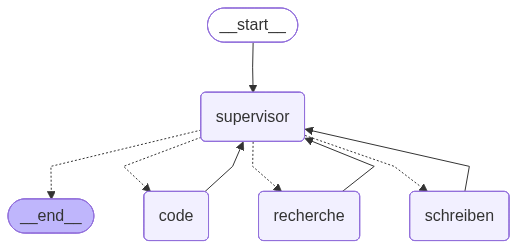

In [ ]:
# ── VIZ ──────────────────────────────────────────────────
display(IPImage(resilient_graph.get_graph().draw_mermaid_png()))

In [27]:
# ── TEST: Resilient Graph mit normalem Task ───────────────────────────────
aufgabe3 = "Recherchiere Python-Decorators und erstelle ein Code-Beispiel."

result3 = resilient_graph.invoke(
    {
        "messages":    [],
        "aufgabe":     aufgabe3,
        "naechster":   "",
        "iterationen": 0,
        "max_iter":    6,
    },
    config={"run_name": "M20-Kap5-Supervisor", "tags": ["m20", "resilient"],
            "recursion_limit": 40}
)

mprint("## 🎯 Resilient Graph – Ergebnis")
mprint(f"**Iterationen:** {result3['iterationen']}\n")
for msg in result3["messages"]:
    agent = getattr(msg, "name", None) or "System"
    if agent == "System":
        mprint(f"**⚠️ [{agent}]** {msg.content}")
    else:
        mprint(f"**[{agent}]** {msg.content[:300]}...\n---")

**👔 Supervisor →** `recherche`  _Zuerst Fakten zu Python-Decorators sammeln, bevor der strukturierte Text samt Codebeispiel erstellt wird._


**🤖 Recherche** (resilient) arbeitet...

  ⚠️ Versuch 1 fehlgeschlagen: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT. Wiederhole...

**👔 Supervisor →** `schreiben`  _Recherche ist fehlgeschlagen; wir fahren mit dem Schreiben fort, um basierend auf vorhandenem Wissen eine Erklärung und ein Code-Beispiel zu liefern._


**🤖 Schreiben** (resilient) arbeitet...

**👔 Supervisor →** `FINISH`  _Agent-Budget (2 Aufrufe) ist erreicht: recherche scheiterte, schreiben lieferte Überblick und Code-Beispiel. Weitere Agenten sind laut Vorgabe nicht erlaubt, daher Abschluss._

## 🎯 Resilient Graph – Ergebnis

**Iterationen:** 2


**⚠️ [System]** ❌ Recherche konnte Aufgabe nicht erfüllen nach 2 Versuchen: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

**[Schreiben]** ## Gliederung für "Python-Decorators"

1. **Einleitung & Definition**
   - Was sind Python-Decorators?
   - Grundlegende Funktionsweise

2. **Historische Entwicklung**
   - Entstehung und Evolution von Decorators in Python

3. **Aktuelle Anwendungen**
   - Beispiele für den Einsatz von Decorators in...
---

# 6 | Debugging & Best Practices
---


<p><font color='black' size="5">
Nachrichten analysieren
</font></p>

Nach einem Graph-Lauf lässt sich die Zusammenarbeit der Agents detailliert auswerten.

In [28]:
# ── Nachrichten-Analyse nach dem Graph-Lauf ──────────────────────────────
def analysiere_lauf(result: dict, title: str = "Lauf-Analyse"):
    """Analysiert einen Graph-Lauf: Agent-Beiträge, Nachrichten-Längen."""
    messages = result["messages"]
    agent_beitraege = {}
    for msg in messages:
        name = getattr(msg, "name", None) or "Unbekannt"
        agent_beitraege[name] = agent_beitraege.get(name, 0) + 1

    mprint(f"## 📊 {title}")
    mprint(f"**Gesamt Nachrichten:** {len(messages)}")
    mprint(f"**Iterationen:** {result.get('iterationen', '–')}")
    mprint("\n**Agent-Beiträge:**")
    for agent, count in sorted(agent_beitraege.items()):
        mprint(f"  - `{agent}`: {count}x")

    # Längste Nachricht
    laengste = max(messages, key=lambda m: len(m.content))
    mprint(f"\n**Längste Nachricht:** `{getattr(laengste, 'name', '?')}` "
           f"({len(laengste.content)} Zeichen)")


# Analyse für beide Test-Läufe
analysiere_lauf(result1, "Test 1: Recherche + Schreiben")

print()
try:
    analysiere_lauf(result2, "Test 2: Recherche + Code")
except NameError:
    mprint("⚠️ `result2` nicht definiert – Kap 4.2 zuerst ausführen.")

## 📊 Test 1: Recherche + Schreiben

**Gesamt Nachrichten:** 2

**Iterationen:** 2


**Agent-Beiträge:**

  - `Recherche`: 1x

...

**Iterationen:** 2


**Agent-Beiträge:**

  - `Code`: 1x

  - `Recherche`: 1x


**Längste Nachricht:** `Code` (2005 Zeichen)


<p><font color='black' size="5">
Best Practices: Supervisor Pattern
</font></p>

| Aspekt | Empfehlung |
|--------|------------|
| **Agent-Anzahl** | 3-5 Agents; mehr → Hierarchisches Pattern (M30) |
| **Supervisor-Prompt** | Klare Reihenfolge-Empfehlungen angeben |
| **Iterations-Schutz** | Immer `max_iter` IM State + `recursion_limit` in Config |
| **Nachrichten-Kontext** | Zu lange Histories → Kosten steigen, Quality sinkt → trimmen |
| **Tool-Fehler** | Resiliente Nodes mit Try/Except + Fehlernachricht |
| **Begründungs-Feld** | `begruendung` im Pydantic-Modell für Debugging |
| **LangSmith** | `run_name` + `tags` für alle Runs setzen |

**Häufige Fehler**

| Fehler | Ursache | Lösung |
|--------|---------|--------|
| Endlosschleife | Supervisor kommt nicht zu FINISH | `max_iter` + `recursion_limit` |
| Floating Nodes | Router gibt `END`-Konstante zurück | `"__end__"` (String) + `path_map` |
| Leere Antworten | Agent erhält zu wenig Kontext | Aufgaben-Feld im State mitgeben |
| Hohe Kosten | Zu viele Supervisor-Calls | `with_structured_output` + gute Prompts |
| Falsche Reihenfolge | Supervisor-Prompt unklar | Konkrete Reihenfolgen im Prompt |

**Supervisor vs. Pipeline – Entscheidungshilfe**

```
Aufgabe hat immer dieselben Schritte?
  → JA: Pipeline (→ *Multi-Agent Patterns*)
  → NEIN: Schritte hängen von Zwischen-Ergebnissen ab?
      → JA: Supervisor (dieses Modul)
      → NEIN: Brauche ich mehrere Teams?
          → JA: Hierarchisch (→ *Hierarchical Agent Teams*)
```

In [29]:
#@title
#@markdown   <p><font size="4" color='green'>  LangSmith Trace-Analyse</font> </br></p>

import time as _t; _t.sleep(2)
show_trace("M20-Supervisor-Pattern", limit=3, show_steps=True)

## LangSmith Trace — `M20-Supervisor-Pattern`

| Run | Status | Dauer | Child-Runs |
|-----|--------|-------|------------|
| `M20-Kap5-Supervisor` | ❌ pending | — | 0 |
| `M20-Kap5-Supervisor` | ✅ success | 90.1s | 0 |
| `M20-Kap4.2-Supervisor` | ✅ success | 53.8s | 0 |


### Steps — letzter Run: `M20-Kap5-Supervisor`

| # | Typ | Name | Status | Dauer |
|---|-----|------|--------|-------|
| 1 | `chain` | `supervisor` | ❌ | — |
| 2 | `chain` | `schreiben` | ✅ | 12.2s |
| 3 | `chain` | `supervisor` | ✅ | 6.0s |
| 4 | `chain` | `recherche` | ✅ | 50.6s |
| 5 | `chain` | `supervisor` | ✅ | 4.4s |

# A | Aufgabe
---

<p><font color='darkblue' size="4">
📌 <b>Wichtig</b>
</font></p>

Die Aufgabestellungen unten bieten Anregungen, Sie können aber auch gerne eine andere Herausforderung angehen.

**Hinweis zur Lösungshilfe:**
> In diesem Kurs dürfen und sollen Sie generative KI auch als Unterstützung beim Lernen und Entwickeln nutzen. Wenn Sie bei einer Aufgabe festhängen, können Sie zum Beispiel Gemini in Google Colab verwenden, um Fehlermeldungen besser zu verstehen, Ideen für Teilschritte zu bekommen oder Code-Varianten zu prüfen.
> <br>**Wichtig ist nur:** Die KI dient als Lern- und Entwicklungshilfe. Der Schwerpunkt des Kurses bleibt darauf, KI-Agenten selbst zu verstehen, aufzubauen und gezielt weiterzuentwickeln.



<p><font color='black' size="5">
Aufgabe 1: Critique Agent hinzufügen
</font></p>

Erweitere das Supervisor-System um einen **Critique-Agent**, der Output bewertet:

```python
class KritikBewertung(BaseModel):
    punktzahl:  int  # 1-10
    feedback:   str
    genehmigt:  bool

@tool
def bewertung_speichern(bewertung: str) -> str:
    """Speichert eine Bewertung für den Bericht."""
    ...
```

- Critique-Agent prüft den Schreib-Agent-Output
- Bei `genehmigt=False` → Supervisor schickt Schreib-Agent erneut
- Maximal 2 Kritik-Runden



<p><font color='black' size="5">
Aufgabe 2: Nachrichten-Trimming
</font></p>

Lange Agent-Historien erhöhen Kosten und Latenz. Implementiere Trimming:

```python
from langchain_core.messages import trim_messages

def supervisor_node_mit_trimming(state: SupervisorState) -> dict:
    # Nur die letzten N Tokens an den Supervisor senden
    gekuerzte_messages = trim_messages(
        state["messages"],
        max_tokens=2000,
        strategy="last",
        token_counter=llm,
    )
    entscheidung = supervisor_llm.invoke([...])
    ...
```



<p><font color='black' size="5">
Aufgabe 3: Parallele Worker-Ausführung
</font></p>

Nutze LangGraphs `Send()` API um mehrere Agents gleichzeitig zu starten:

```python
from langgraph.types import Send

def supervisor_parallel(state: SupervisorState):
    """Startet Recherche und Code-Agent gleichzeitig."""
    return [
        Send("recherche", state),
        Send("code",      state),
    ]
```

**Bonus:** Kombiniere mit HITL (aus *Human-in-the-Loop*) – Mensch genehmigt den finalen Bericht  
und Checkpointing (aus *Checkpointing & Sessions*) – Berichte persistent in SQLite speichern.

---
### 🔍 Selbstcheck mit `assert`

`assert` prüft eine Bedingung — ist sie `False`, stoppt Python mit einem `AssertionError` und zeigt die Fehlermeldung an:

```python
assert bedingung, "Fehlermeldung"

assert 2 + 2 == 4, "Rechnung falsch"    # ✅ kein Fehler
assert len("Hi") > 5, "Text zu kurz"   # ❌ AssertionError: Text zu kurz
```

**So nutzen Sie den Selbstcheck:**
1. Erweitern Sie das Supervisor-System in den Zellen über diesem Block (Critique Agent, Trimming oder Send)
2. Speichern Sie Ihren erweiterten Graph in **`mein_supervisor`** (`mein_supervisor = builder.compile()`)
3. Führen Sie die Zelle unten aus — Supervisor-Routing und Worker-Output werden geprüft


In [30]:
#@title ✅ Selbstcheck – Erweiterter Supervisor  { display-mode: "form" }
# ► Speichere deinen erweiterten Supervisor-Graph in 'mein_supervisor'.

if "mein_supervisor" not in dir():
    print("⚠️  'mein_supervisor' nicht definiert.")
    print("   Löse zuerst Aufgabe 1, 2 oder 3 und speichere deinen Graph:")
    print("   mein_supervisor = builder.compile()")
else:
    _g = mein_supervisor

    assert hasattr(_g, "invoke"), \
        "❌ Graph hat kein invoke() – wurde builder.compile() aufgerufen?"

    _r = _g.invoke(
        {
            "messages":    [],
            "aufgabe":     "Schreibe einen Satz über KI-Agenten.",
            "naechster":   "",
            "iterationen": 0,
            "max_iter":    4,
        },
        config={"recursion_limit": 20},
    )

    assert "messages" in _r and len(_r["messages"]) > 0, \
        "❌ Keine Messages – Supervisor hat nicht geroutet"

    _worker_names = [m.name for m in _r["messages"] if getattr(m, "name", None)]
    assert len(_worker_names) > 0, \
        "❌ Kein Worker-Output – prüfe make_worker_node() und Supervisor-Routing"

    print(f"✅ Supervisor-Graph durchgelaufen")
    print(f"   Worker aufgerufen: {set(_worker_names)}")
    print(f"   {len(_r['messages'])} Nachrichten · Iterationen: {_r.get('iterationen', '?')}")
    print(f"   {_r['messages'][-1].content[:120]}{'...' if len(_r['messages'][-1].content) > 120 else ''}")

⚠️  'mein_supervisor' nicht definiert.
   Löse zuerst Aufgabe 1, 2 oder 3 und speichere deinen Graph:
   mein_supervisor = builder.compile()
